In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import os
from glob import glob
from scipy.stats import linregress, pearsonr
from sklearn.metrics import mean_squared_error

matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

## Meta Gene Plot

In [2]:
metafile = pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/PEC_donor_LIMS.csv')
qcfile = pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/metadata_DNA_QC.tsv.gz',index_col = [0],compression='gzip', header=0, sep='\t')

In [3]:
geneRef = pd.read_csv('/cndd2/jchien/iGenome/gencodev37/gencode.v37.annotation.intragenic_filter.bed.gz',sep='\t',index_col=[3,6],names = ['chr','start','end','strand','class','biotype'])
geneRef = geneRef.loc[~ geneRef['chr'].isin(['chrY'])]
geneRef['length'] = np.log10(geneRef['end'] - geneRef['start'])

In [4]:
def categorize_values(column,num_level = 10):

    filtered_column = column[column != 0]


    percentiles = [filtered_column.quantile(i/num_level) for i in range(1,num_level)]
    conditions = [column == 0]
    categories = ['0']

    # Add conditions for each percentile
    last_percentile = 0
    for i, percentile in enumerate(percentiles):
        conditions.append((column > last_percentile) & (column <= percentile))
        #categories.append(f'{int((i / 10) * 100)}%~{int(((i + 1) / 10) * 100)}%')
        categories.append(i+1)
        last_percentile = percentile

    # Add the condition for values greater than the last percentile
    conditions.append(column > percentiles[-1])
    categories.append(str(num_level))

    # Apply the conditions to categorize
    return np.select(conditions, categories, default='unknown')


In [5]:
bincs=[]
coverages = []
datadir = os.path.join('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/regionMethylation/stranded_genebody_flanking/merged')

for ctxt in ['CG','CH']:
    for age_group in ['Infancy', 'Early_Childhood','Late_Childhood','Adolescence','Adulthood','Late_Adulthood']:
        for celltype in ['GABA','GLU']:
            for mctype in ['BS','OXBS']:
                if ctxt == 'CH' and mctype == 'OXBS':
                    continue
                for strand in ['Watson','Crick']:
                    binc_file=glob(f'{datadir}/{celltype}_{mctype}_{age_group}*{ctxt}N-{strand}.sparse.bed.gz')                
                    binc=pd.read_csv(binc_file[0],sep='\t',index_col=[3,6],names = ['chr','start','end','gene','class','mCG','CG'])
                    binc = binc[~binc['chr'].isin(['chrY'])]
                
                    binc_coverage =binc.filter(regex=r'^C')
                    binc_ratio = pd.DataFrame({f'm{strand}': binc['mCG']/binc['CG']})
                    multi_index = pd.MultiIndex.from_tuples([(age_group,celltype,mctype,ctxt,strand)],names = ['period','celltype', 'mctype','ctxt','strand'])
                    
                    binc_ratio.columns = multi_index
                    binc_coverage.columns = multi_index

                
                    bincs.append(binc_ratio)
                    coverages.append(binc_coverage)

bincs = [x for x in bincs if x is not None]
binc=bincs[0].join(bincs[1:],how='inner')

In [6]:
coverages = [x for x in coverages if x is not None]
coverage=coverages[0].join(coverages[1:],how='inner')
coverage.head()   

period                Infancy                                               \
celltype                 GABA                       GLU                      
mctype                     BS         OXBS           BS         OXBS         
ctxt                       CG           CG           CG           CG         
strand                 Watson Crick Watson Crick Watson Crick Watson Crick   
ENSG00000237491.10 30     248   330    152   307    300   402    175   266   
                   31     362   447    212   287    360   417    217   259   
                   32     243   248    136    93    231   208    185   148   
                   33     266   243    218   158    345   276    217   152   
                   34     100   110     45   129     85   134     61   103   

period                Early_Childhood        ... Adolescence        Adulthood  \
celltype                         GABA        ...         GLU             GABA   
mctype                             BS        ...          BS               BS   
ctxt                               CG        ...          CH               CH   
strand                         Watson Crick  ...      Watson  Crick    Watson   
ENSG00000237491.10 30             500   661  ...       19237  18809     25016   
                   31             694   887  ...       20514  17879     24423   
                   32             528   435  ...       17247   8994     20860   
                   33             647   556  ...       15875  14731     20558   
                   34             187   218  ...       11642  13841     14981   

period                                     Late_Adulthood                       
celltype                        GLU                  GABA           GLU         
mctype                           BS                    BS            BS         
ctxt                             CH                    CH            CH         
strand                 Crick Watson  Crick         Watson  Crick Watson  Crick  
ENSG00000237491.10 30  25134  26901  26087          11912  11692  16224  15032  
                   31  22202  25333  22588          10192   9239  13403  13267  
                   32  12339  21908  13342          10076   6184  11672   8229  
                   33  16677  21472  20175           9520   7950  11654  10943  
                   34  15684  16206  19827           6815   7207   8676   9630  

[5 rows x 72 columns]

In [7]:
coverage_filter = coverage.copy()

In [8]:
for ctxt in ['CG','CH']:
    for age_group in ['Infancy', 'Early_Childhood','Late_Childhood','Adolescence','Adulthood','Late_Adulthood']:
        for celltype in ['GABA','GLU']:
            for mctype in ['BS','OXBS']:
                if ctxt == 'CH' and mctype == 'OXBS':
                    continue
                watson = coverage_filter[(age_group,celltype,mctype,ctxt,'Watson')]
                crick = coverage_filter[(age_group,celltype,mctype,ctxt,'Crick')]
                diff = np.abs(watson - crick)
                min_values = np.maximum(watson , crick)
                condition = diff > 0.2 * min_values
                
                # Apply the condition to mark as NA
                coverage_filter.loc[condition, [(age_group,celltype,mctype,ctxt,'Watson'), (age_group,celltype,mctype,ctxt,'Crick')]] = np.nan

In [9]:
binc_filter = binc.copy()
binc_filter = binc_filter.where(coverage_filter.notna())
binc_hmC = binc.loc[:,(slice(None),slice(None),'BS','CG',slice(None))]
binc_hmC = binc_hmC - binc.loc[:,(slice(None),slice(None),'OXBS','CG',slice(None))].values
binc_hmC[binc_hmC < 0] = np.nan
#binc_hmC = binc_hmC.dropna()
binc_hmC.columns.set_levels(['hmc'], level='mctype', inplace=True)

/tmp/ipykernel_1913043/3865126972.py:7: FutureWarning: inplace is deprecated and will be removed in a future version.
  binc_hmC.columns.set_levels(['hmc'], level='mctype', inplace=True)


In [5]:
expression = pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/RNA_expression_TPM.tsv.gz',sep = '\t',index_col = [0])
# expression = pd.read_csv('/datasets/Public_Datasets/Dracheva_PsychEncode_development/processed/RNA_expression_log2CPM+1.tsv.gz',sep = '\t',index_col = [0])
ave_expression = pd.DataFrame(np.log2(expression + 1))

# Separate the columns by cell type
gaba_columns = [col for col in expression.columns if 'GABA' in col]
glu_columns = [col for col in expression.columns if 'GLU' in col]

# Calculate average expression per cell type
ave_expression['GABA'] = ave_expression[gaba_columns].mean(axis=1)
ave_expression['GLU'] = ave_expression[glu_columns].mean(axis=1)

In [7]:
period_palette={'Infancy': '#F7C98A',
'Early_Childhood': '#F4A154',
'Late_Childhood': '#EF7A3B',
'Adolescence': '#D2614D',
'Adulthood': '#9D4255',
'Late_Adulthood': '#774147',
        }

In [8]:
geneRef = pd.read_csv('./data/gencode.v37.annotation.intragenic.bed.gz',sep='\t',index_col=[3,6],names = ['chr','start','end','strand','class','biotype'])
geneRef = geneRef.loc[~ geneRef['chr'].isin(['chrY'])]
geneRef['length'] = np.log10(geneRef['end'] - geneRef['start'])

In [ ]:
geneRef_filter = geneRef[(geneRef['biotype'].isin(['lncRNA', 'protein_coding'])) & (geneRef['length'] >= 3) & (geneRef['chr'] != 'chrX')  & (geneRef['chr'] != 'chrY') & (geneRef.index.get_level_values(0).isin(binc_filter.index.get_level_values(0)))]
geneRef_filter_reset = geneRef_filter.reset_index(level=0).rename(columns={'level_0': 'gene'})
geneRef_filter_reset

/tmp/ipykernel_1913043/3441358458.py:67: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


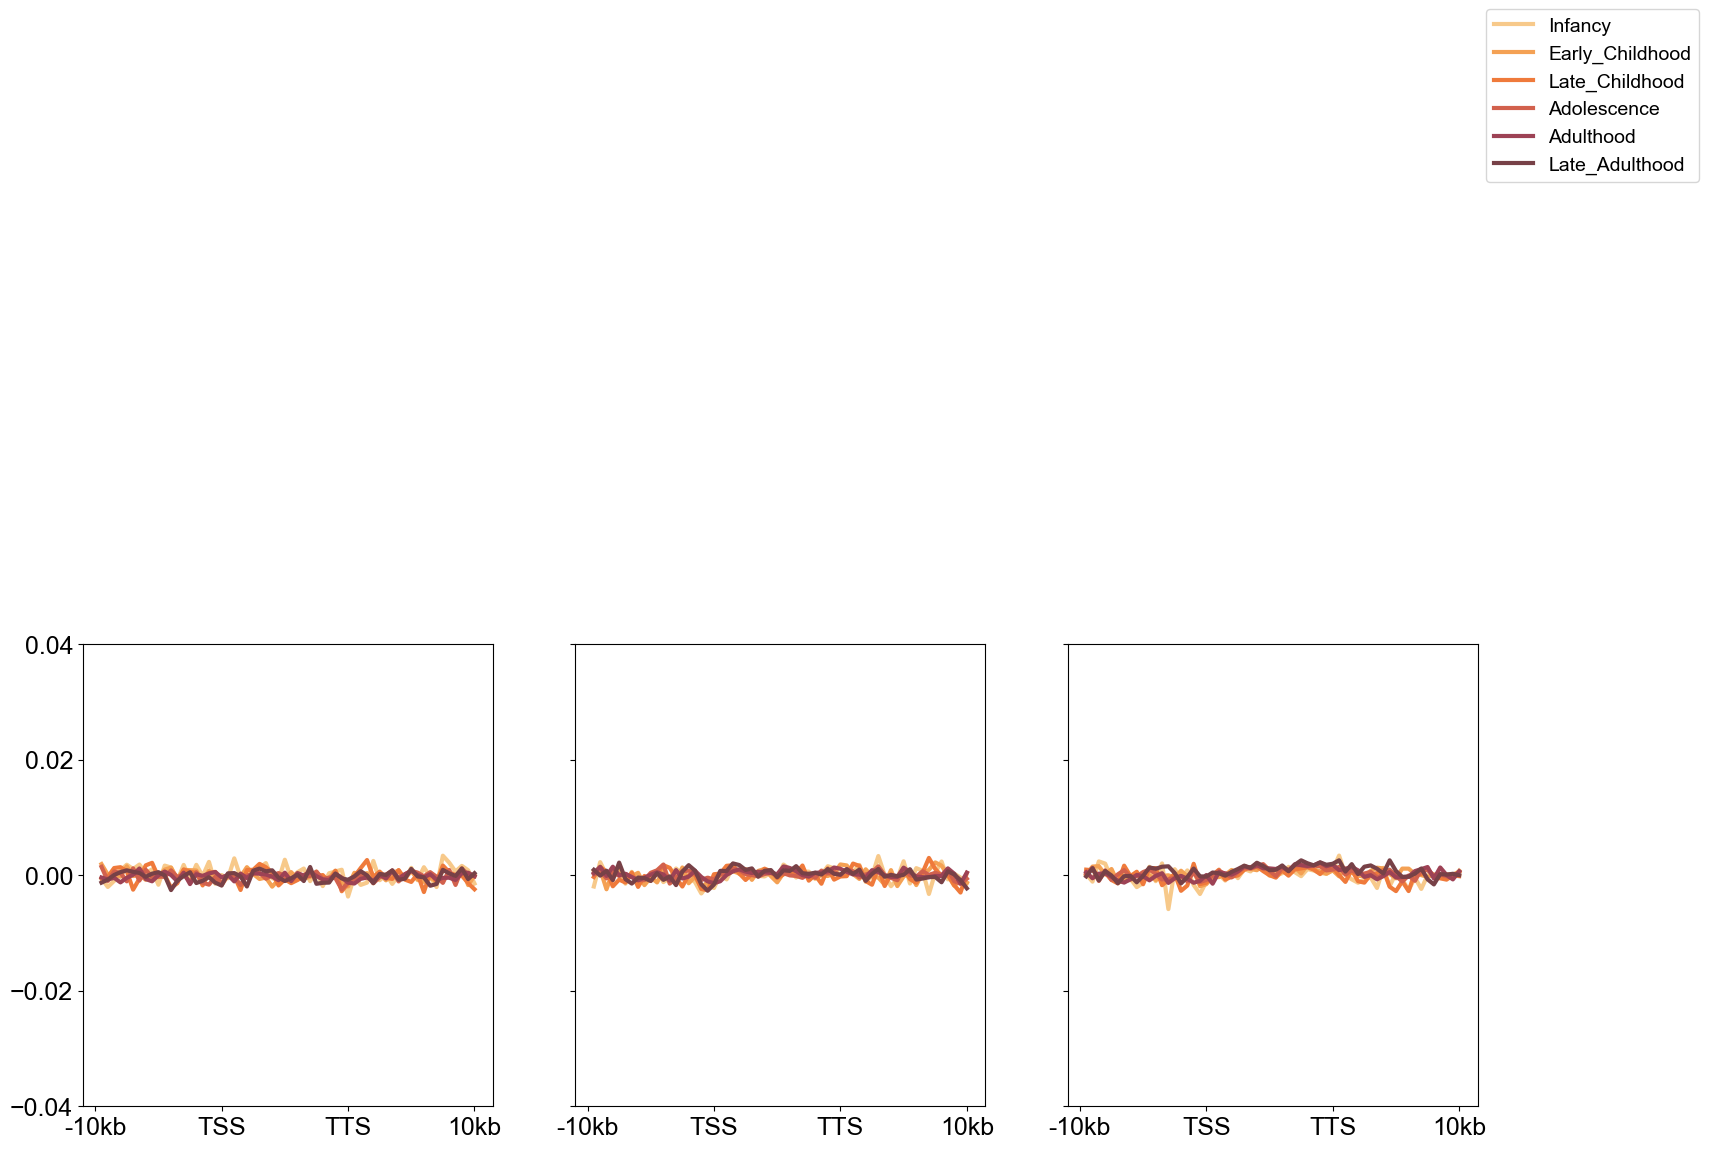

/tmp/ipykernel_1913043/3441358458.py:67: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


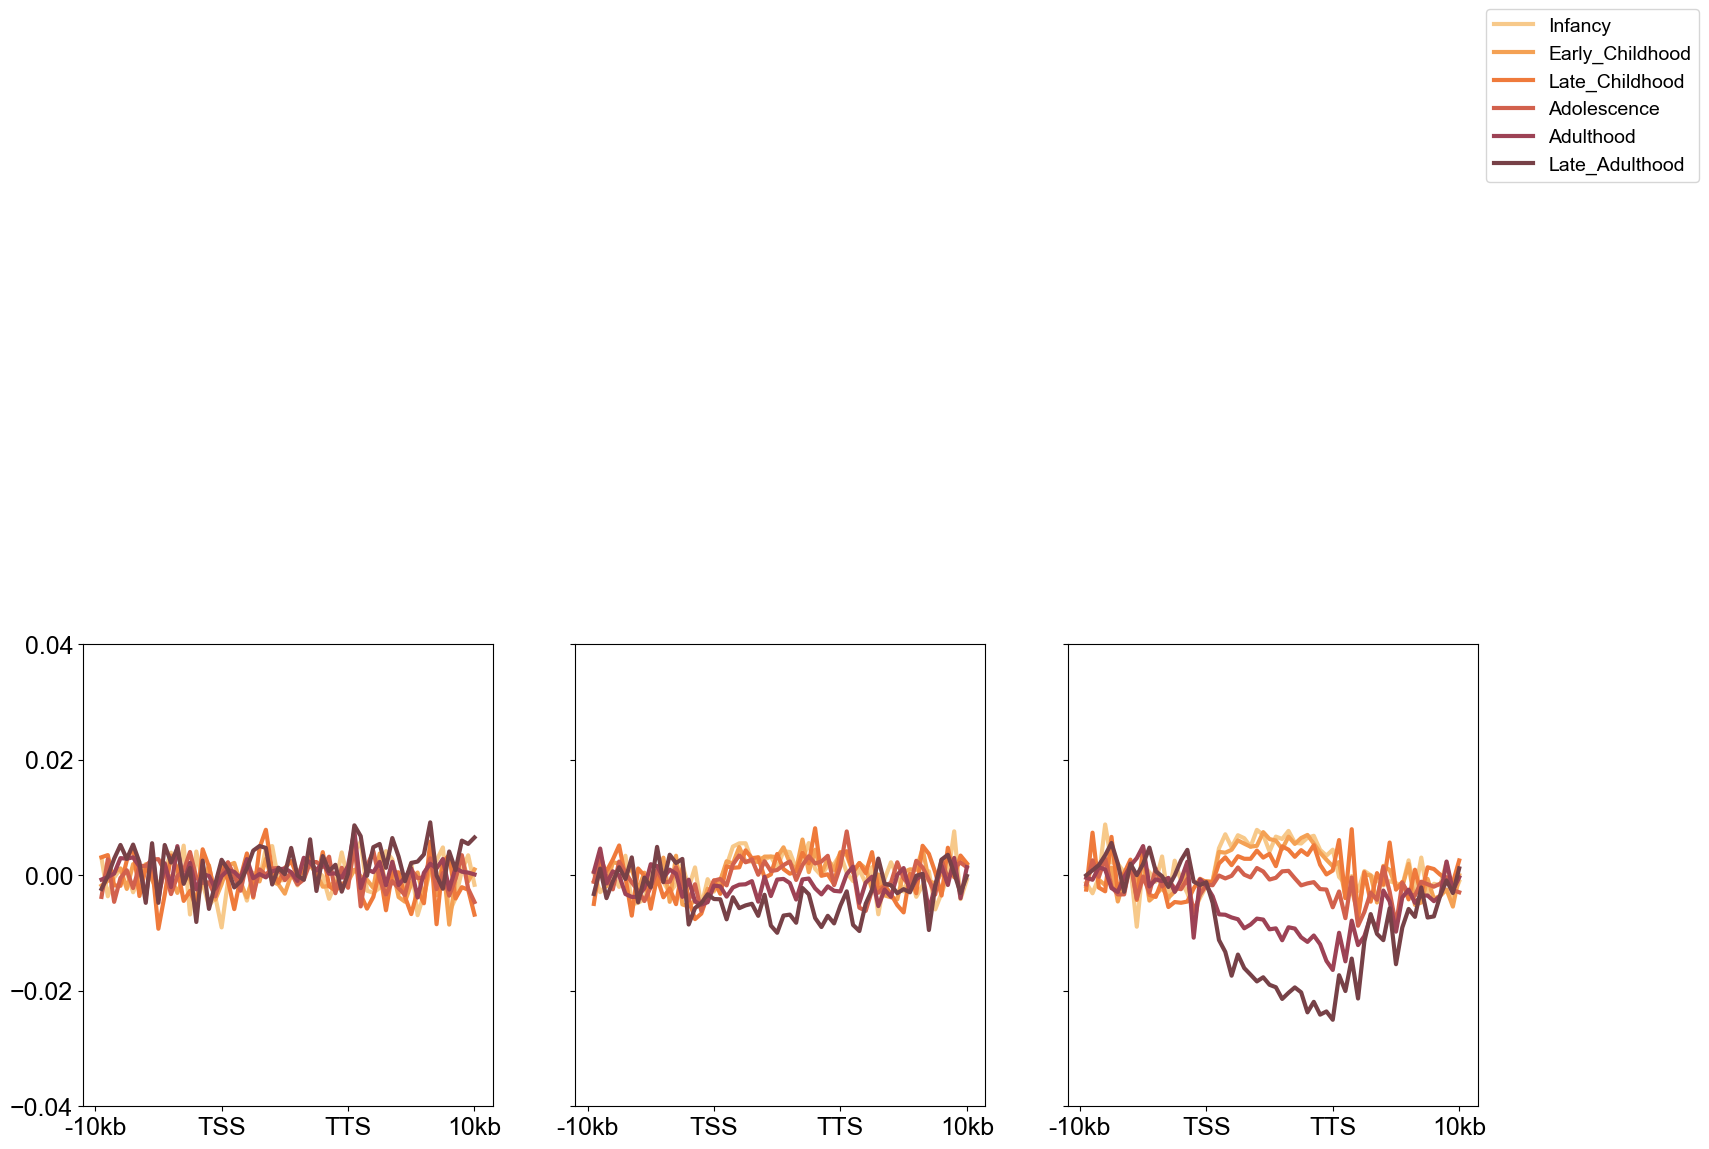

/tmp/ipykernel_1913043/3441358458.py:67: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


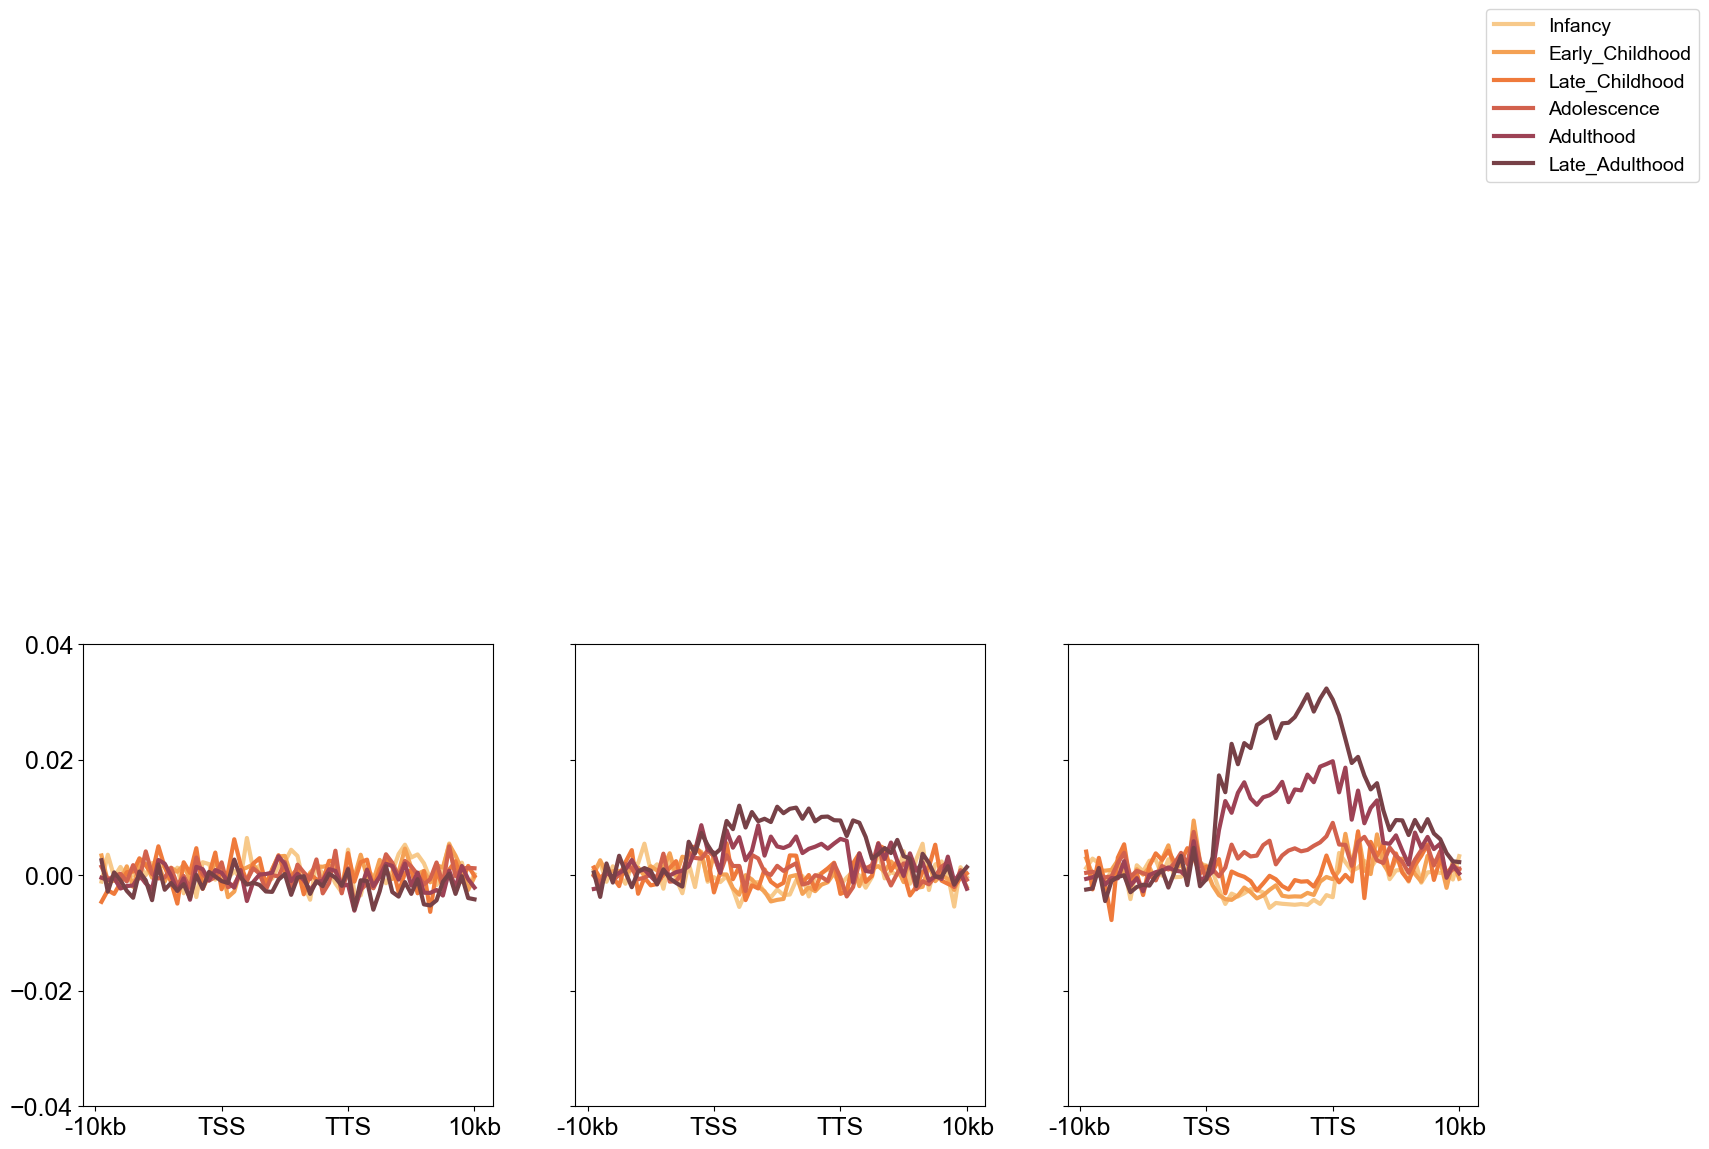

In [16]:
celltype = 'GABA'
ctxt = 'CG'
num_levels = 10
categorized_ave_expression = ave_expression.loc[geneRef_filter.index.get_level_values(0), [celltype]].copy()
categorized_ave_expression['lifetime'] = categorized_ave_expression.mean(axis = 1) 
categorized_ave_expression = categorized_ave_expression.apply(lambda col: categorize_values(col, num_levels))
categorized_ave_expression = categorized_ave_expression.reset_index().rename(columns={'index': 'geneID'})
categorized_ave_expression = categorized_ave_expression.melt(id_vars=['geneID'], var_name='age_group', value_name='RNA')


metrics = ['BS','OXBS','hmc']
for i, metric in enumerate(metrics):
    fig, axes = plt.subplots(1, 3, figsize=(18,2*(1+2)),sharey=True)

    axes = axes.flatten()
    legend_order = ['Infancy', 'Early_Childhood','Late_Childhood','Adolescence','Adulthood','Late_Adulthood']

    for idx, age_group in enumerate(legend_order):
        if metric == 'hmc':
            binc_subset = binc_hmC.loc[:,(age_group,celltype,metric,ctxt,slice(None))]
        else:
            binc_subset = binc_filter.loc[:,(age_group,celltype,metric,ctxt,slice(None))]
        binc_subset = binc_subset.reset_index() 
        binc_subset.columns = ['gene','bin_index','sense','anti-sense']
        binc_subset = pd.merge(binc_subset, geneRef_filter_reset[['gene','strand']],left_on = 'gene',right_on = 'gene')
        mask = binc_subset['strand'] == '-'
        binc_subset.loc[mask, ['sense','anti-sense']] = binc_subset.loc[mask, ['anti-sense','sense']].values
        binc_subset = binc_subset.set_index(['gene','bin_index','strand'])
        figure_index = 0
        for level in [1,7,10]:
            
            ax = axes[figure_index]
            figure_index = figure_index + 1
            gene_subset = categorized_ave_expression[(categorized_ave_expression['age_group'] == 'lifetime') & (categorized_ave_expression['RNA'] == str(level))]['geneID']

            binc_subset_grouped = binc_subset.loc[binc_subset.index.get_level_values(0).isin(gene_subset), ].groupby(level=1).mean()
            binc_subset_grouped['diff'] = binc_subset_grouped['sense'] - binc_subset_grouped['anti-sense']
            binc_subset_grouped_melt = binc_subset_grouped.reset_index().melt(id_vars = 'bin_index',value_vars = ['sense','anti-sense','diff'])

            binc_subset_grouped_melt_plot = binc_subset_grouped_melt[binc_subset_grouped_melt['variable'] == 'diff']          
            ax.plot(binc_subset_grouped_melt_plot['bin_index'], binc_subset_grouped_melt_plot['value'], 
                        label=age_group,color=period_palette[age_group],   linewidth= 3)
            ax.set_xticks([0, 20, 40, 60])
            #ax.set_yticks([i/ 100  for i in [*range(0,70,5)]])
            ax.set_yticks([-0.04,-0.02,0,0.02,0.04])
            ax.tick_params(axis='y', labelsize=18)
            
            ax.set_xticklabels(['-10kb', 'TSS', 'TTS', '10kb'],fontsize = 18)

            if metric == 'OXBS':
                y_label = f'mCG Strand Difference'
            elif metric == 'BS':
                y_label = f'tmCG Strand Difference'
            else:
                y_label = f'hmCG Strand Difference'
            ax.set_ylabel('',fontsize = 18) #
            ax.set_title(f'',fontsize = 18) #
            if level != 10:
                ax.legend().set_visible(False)
                ax.set_xlabel('')  # Hide xlabel for first two plots
            else:
                # Only show legend on third plot
                handles, labels = ax.get_legend_handles_labels()
                ax.legend(handles=handles, labels=labels, loc='lower left', bbox_to_anchor=(1.02, 2), borderaxespad=0.,prop={'size': 14})


    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)
    if metric == 'OXBS':
        filename = f'{celltype}_mCG_genebody+10kb.pdf'
    elif metric == 'BS':
        filename = f'{celltype}_tmCG_genebody+10kb.pdf'
    else:
        filename = f'{celltype}_hmCG_genebody+10kb.pdf'
    # plt.savefig(filename,transparent=True)
    plt.show()

## Individual Donor Scatter Plot

In [34]:
geneRef = pd.read_csv('/cndd2/jchien/iGenome/gencodev37/gencode.v37.annotation.intragenic_filter.bed.gz',sep='\t',index_col=[3,6],names = ['chr','start','end','strand','class','biotype'])
geneRef = geneRef.loc[~ geneRef['chr'].isin(['chrY'])]
geneRef['length'] = np.log10(geneRef['end'] - geneRef['start'])

In [35]:
def read_binc(path):
    df = pd.read_csv(
        path,
        # sep="\t",
        compression="gzip",
        header=[0,1,2,3,4,5],   # 6 header rows = your 6 MultiIndex levels
        index_col=[0,1]         # your original (class, type) index becomes first 2 cols
    )

    # (Optional) restore index names if needed
    df.columns.names = ["subject", "sex", "period", "celltype", "mctype", "strand"]
    return df

binc = read_binc("/cndd/hex002/PsychEncode/methylation/strand_biased/Individual_mCG.tsv.gz")
coverage = read_binc("/cndd/hex002/PsychEncode/methylation/strand_biased/Individual_mCG_cov.tsv.gz")

In [36]:
def mask_watson_crick_pairs_optimized(df,threshold = 0.2):
    
    df_masked = df.copy()

    # Identify all unique subjects in the DataFrame
    subjects = df.columns.get_level_values(0).unique()

    
    for subject in subjects:
        for celltype in df_masked.loc[:,subject].columns.get_level_values(2).unique():
            for mctype in df_masked.loc[:,subject].columns.get_level_values(3).unique():

                watson_vals = df_masked.xs(('Watson'), level='strand', axis=1, drop_level=True).loc[:, (subject,slice(None),slice(None),celltype,mctype)]
                crick_vals = df_masked.xs(('Crick'), level='strand', axis=1, drop_level=True).loc[:, (subject,slice(None),slice(None),celltype,mctype)]
                
                # Calculate the condition for masking
                condition = abs(watson_vals - crick_vals) >  threshold * np.minimum(watson_vals, crick_vals)
                
                condition_flat = condition.any(axis=1)
                
                df_masked.loc[condition_flat, (subject, slice(None), slice(None), celltype,mctype, ['Watson','Crick'])] = np.nan

    return df_masked

In [37]:
coverage_masked = mask_watson_crick_pairs_optimized(coverage,threshold=0.2)
binc_updated = binc.where(pd.notna(coverage_masked))

In [38]:
# binc = binc.dropna()
binc_hmC = binc.loc[:,(slice(None),slice(None),slice(None),slice(None),'BS',slice(None))]
binc_hmC = binc_hmC - binc.loc[:,(slice(None),slice(None),slice(None),slice(None),'OXBS',slice(None))].values
binc_hmC[binc_hmC < 0] = np.nan
binc_hmC = binc_hmC.dropna()
binc_hmC.columns = binc_hmC.columns.set_levels(['hmc'], level='mctype')

In [39]:
binc_hmC_updated = binc_hmC.copy()
for subject in binc_hmC.columns.get_level_values(0).unique():
    for celltype in binc_hmC.loc[:,subject].columns.get_level_values(2).unique():

        condition = binc_updated.loc[:,(subject,slice(None),slice(None),celltype,slice(None),slice(None))].isna().any(axis = 1)
        
        binc_hmC_updated.loc[condition, (subject, slice(None), slice(None), celltype,'hmc', ['Watson','Crick'])] = np.nan

In [40]:
num_level = 10

In [41]:
gene_strand_diff = []
for celltype in ['GLU','GABA']:
    include_SCZ = np.unique(qcfile[qcfile['DNA_passQC'] != 'False']['donor'])
    categorized_ave_expression = ave_expression[ave_expression.index.isin(geneRef_filter.index.get_level_values(0))]
    categorized_ave_expression = categorized_ave_expression.apply(lambda col: categorize_values(col, num_level))
    categorized_ave_expression = categorized_ave_expression.reset_index().rename(columns={'index': 'geneID'})
    categorized_ave_expression = categorized_ave_expression.melt(id_vars=['geneID'], var_name='age_group', value_name='RNA')
    categorized_ave_expression = categorized_ave_expression[categorized_ave_expression['age_group'] == celltype]

    
    target_genes = categorized_ave_expression[categorized_ave_expression['RNA'] == '10']['geneID']
    
    # For hmCG

    binc_subset = binc_hmC_updated.loc[:,(include_SCZ,slice(None),slice(None),celltype,'hmc',slice(None))]

    # For mCG
    # binc_subset = binc_updated.loc[:,(include_SCZ,slice(None),slice(None),celltype,'OXBS',slice(None))]

    
    df_melted = binc_subset.melt(var_name=['subject', 'sex', 'period', 'celltypr', 'mctypr', 'strand'], ignore_index=False)

    df_melted.reset_index(inplace=True)
    df_melted = df_melted[['level_0', 'level_1','subject', 'strand', 'value']]
    df_melted.columns = ['geneID','gene', 'subject', 'strand', 'value']
    df_melted.dropna(inplace = True)

    df_pivot = df_melted.pivot_table(index=['geneID','gene','subject'], columns='strand', values='value').reset_index()

    df_pivot['difference'] = df_pivot['Watson'] - df_pivot['Crick']

    df_merged = df_pivot.merge(geneRef, left_on=['geneID','gene'], right_index=True)

    df_merged['adjusted_difference'] = np.where(df_merged['strand'] == '+', df_merged['difference'], -df_merged['difference'])
    df_merged = df_merged[['geneID','subject','adjusted_difference','length']]
    df_merged = df_merged.merge(qcfile[['donor','age','sex']].reset_index(drop=True).drop_duplicates(), left_on='subject', right_on='donor', how='left').drop(columns='donor')
    grouped = df_merged[df_merged['geneID'].isin(target_genes)].groupby(['subject', 'age','sex'])['adjusted_difference'].agg(['mean', 'sem']).reset_index()
    grouped['SCZ'] = [qcfile[(qcfile['donor'] == i)  & (qcfile['celltype'] == celltype)]['DNA_passQC'].iloc[0] for i in grouped['subject']]
    grouped['celltype']   = celltype
    gene_strand_diff.append(grouped)

gene_strand_diff = pd.concat(gene_strand_diff)

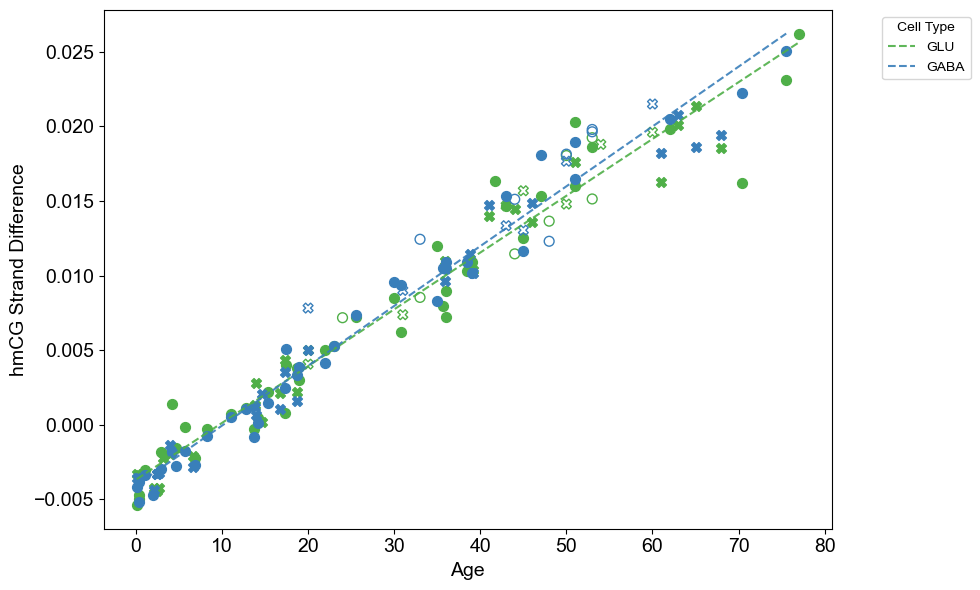

In [42]:

fig, ax = plt.subplots(figsize=(10, 6))

celltype_palette = {'GLU': '#4FAF48', 'GABA': '#397FBA'}

# Scatter plot and regression lines for GLU and GABA
for celltype in ['GLU', 'GABA']:
    subset = gene_strand_diff[gene_strand_diff['celltype'] == celltype]
    
    # Scatter plot
    for sex in ['Male', 'Female']:
        for scz in ['True', 'SCZ']:
            subset_group = subset[
                (subset['sex'] == sex) & 
                (subset['SCZ'] == scz)
            ]
            
            color = celltype_palette[celltype]
            marker = 'o' if sex == 'Male' else 'X'
            
            # Plot points
            if scz == 'SCZ':
                ax.scatter(
                    subset_group['age'], subset_group['mean'],
                    marker=marker, s=50, facecolors='none', edgecolors=color,
                    alpha=1
                )
            else:
                ax.scatter(
                    subset_group['age'], subset_group['mean'],
                    marker=marker, s=50, color=color,
                    alpha=1
                )
    
    # Fit regression line for each cell type
    slope, intercept, r_value, p_value, std_err = linregress(subset['age'], subset['mean'])
    r_pearsonr, p_pearsonr = pearsonr(subset["age"], subset["mean"])

    slope_inv, intercept_inv, r_value_inv, p_value_inv, std_err_inv = linregress(subset['mean'], subset['age'])

    # Predict age from mean
    predicted_age = slope_inv * subset['mean'] + intercept_inv
    rmse_age = np.sqrt(mean_squared_error(subset['age'], predicted_age))
    
    # Define regression line
    x_vals = np.linspace(subset['age'].min(), subset['age'].max(), 200)
    y_vals = slope * x_vals + intercept

    ax.plot(
        x_vals, y_vals, 
        color=celltype_palette[celltype], 
        linestyle='--', linewidth=1.5, alpha=0.9, 
        label=f'{celltype}'
    )
    
    # Annotate slope and R² for each cell type
    # annotation_text = f"{celltype} \nSlope: {slope:.1e} ± {std_err:.1e}\nR²: {r_value**2:.2f} rmse_age: {rmse_age:.2f} \n PearsonR: {r_pearsonr:.2f}, p-value: {p_pearsonr:.2e}"
    # ax.text(0.6, 0.4 if celltype == 'GLU' else 0.1, annotation_text, 
    #         transform=ax.transAxes, fontsize=20, 
    #         color=celltype_palette[celltype], ha='left', va='top',
    #         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Axis labels and settings
ax.set_xlabel('Age', fontsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
# ax.set_ylabel('mCG Strand Difference', fontsize=14)
ax.set_ylabel('hmCG Strand Difference', fontsize=14)

# Legend
ax.legend(title='Cell Type', fontsize=10, loc='upper right', bbox_to_anchor=(1.2, 1))

plt.tight_layout()
# plt.savefig('mCG_HighExpGene_GLU_GABA.pdf')
# plt.savefig('hmCG_HighExpGene_GLU_GABA.pdf')
plt.show()